In [4]:
import matplotlib.pyplot as plt
import os
from TSNE import load_pretrained_encoder
from TSNE import TSNE_pretrained
import pandas as pd
import numpy as np

## Data visualization

In [5]:
# load data expression and labels 
expr = pd.read_parquet("/Users/nourbf/Desktop/geniomhe/hamdi deep Ml/2526-m2geniomhe-SSL-tcga/data/mRNA_coding.omics.parquet")
label=pd.read_parquet("/Users/nourbf/Desktop/geniomhe/hamdi deep Ml/2526-m2geniomhe-SSL-tcga/data/label.parquet")
print('show expression data and shape',expr.head(), expr.shape)
print('show data labels and shape ',label.head(),label.shape)


show expression data and shape                          caseID  ENSG00000211895  ENSG00000211896  \
0  TCGA-HQ-A5ND-01A-11R-A26T-07         0.262200         2.843700   
1  TCGA-G2-A3IB-01A-11R-A20F-07         0.323800         0.444600   
2  TCGA-ZF-AA5N-01A-11R-A42T-07       396.157990        88.736198   
3  TCGA-FD-A6TF-01A-52R-A32O-07        37.804501       894.137695   
4  TCGA-GC-A3WC-11A-11R-A22U-07       737.350281       132.165497   

   ENSG00000211897  ENSG00000211898  ENSG00000211899  ENSG00000211677  \
0           0.1289           0.0000         0.199300         0.655800   
1           0.1120           0.0000         0.082000         0.443000   
2          24.3566           0.2993        10.473400        72.044296   
3          47.8643           2.5348        54.887402       295.739502   
4          35.4646          15.9797        84.176102       212.235199   

   ENSG00000211679  ENSG00000211685  ENSG00000211890  ...  ENSG00000231202  \
0         0.302700           0.0000  

In [6]:

    label["caseID"] = label["cases"].str.split('|').str[1]
    expr["caseID"].str.strip()
    lab=label[["caseID","cancer_type"]]
    print('show data labels and shape ',lab.head(),lab.shape)
    print('show expression data and shape',expr.head(), expr.shape) 
    # merge expression data with labels on caseID
    df=pd.merge(expr,lab, on='caseID', how='inner')

show data labels and shape                           caseID cancer_type
0  TCGA-BL-A0C8-01A-11R-A277-07   TCGA-BLCA
1  TCGA-BT-A20N-01A-11R-A14Y-07   TCGA-BLCA
2  TCGA-BT-A20P-01A-11R-A14Y-07   TCGA-BLCA
3  TCGA-BT-A3PH-01A-11R-A220-07   TCGA-BLCA
4  TCGA-BT-A42C-01A-11R-A23N-07   TCGA-BLCA (10374, 2)
show expression data and shape                          caseID  ENSG00000211895  ENSG00000211896  \
0  TCGA-HQ-A5ND-01A-11R-A26T-07         0.262200         2.843700   
1  TCGA-G2-A3IB-01A-11R-A20F-07         0.323800         0.444600   
2  TCGA-ZF-AA5N-01A-11R-A42T-07       396.157990        88.736198   
3  TCGA-FD-A6TF-01A-52R-A32O-07        37.804501       894.137695   
4  TCGA-GC-A3WC-11A-11R-A22U-07       737.350281       132.165497   

   ENSG00000211897  ENSG00000211898  ENSG00000211899  ENSG00000211677  \
0           0.1289           0.0000         0.199300         0.655800   
1           0.1120           0.0000         0.082000         0.443000   
2          24.3566           0.2

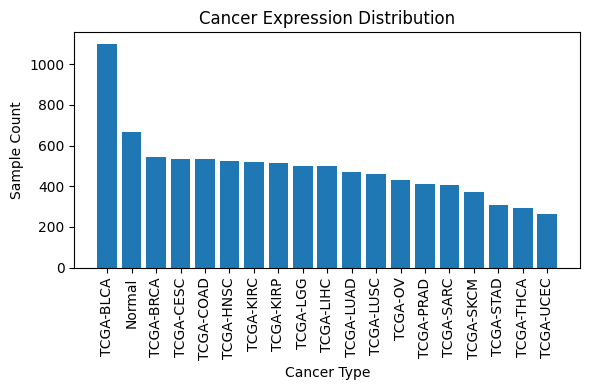

In [7]:
values=df.cancer_type.value_counts()
types=df.cancer_type.unique()
plt.figure(figsize=(6, 4))
plt.bar(types, values)
plt.title("Cancer Expression Distribution")
plt.xlabel("Cancer Type")
plt.ylabel("Sample Count")
plt.xticks(rotation=90)  
plt.tight_layout()
plt.show()

## encoder latent space t-SNE visualization 

In [28]:
import importlib
import TSNE_1
#importlib.reload(TSNE)

In [29]:
from TSNE_1 import TSNE_pretrained

In [ ]:
# load a preprocessed combined data (check preprocess_TCGA.py to see how to generate it)
df2=pd.read_csv('/Users/nourbf/Desktop/geniomhe/hamdi deep Ml/2526-m2geniomhe-SSL-tcga/data/comb.csv')
df2['cancer_type'] = df2['cancer_type'].replace({
    0: 'TCGA-BLCA', 1: 'Normal', 2: 'TCGA-BRCA', 3: 'TCGA-CESC', 4: 'TCGA-COAD',
    5: 'TCGA-HNSC', 6: 'TCGA-KIRC', 7: 'TCGA-KIRP', 8: 'TCGA-LGG', 9: 'TCGA-LIHC',
    10: 'TCGA-LUAD', 11: 'TCGA-LUSC', 12: 'TCGA-OV', 13: 'TCGA-PRAD', 14: 'TCGA-SARC',
    15: 'TCGA-SKCM', 16: 'TCGA-STAD', 17: 'TCGA-THCA', 18: 'TCGA-UCEC'
})

Latent Z shape: (9349, 256)


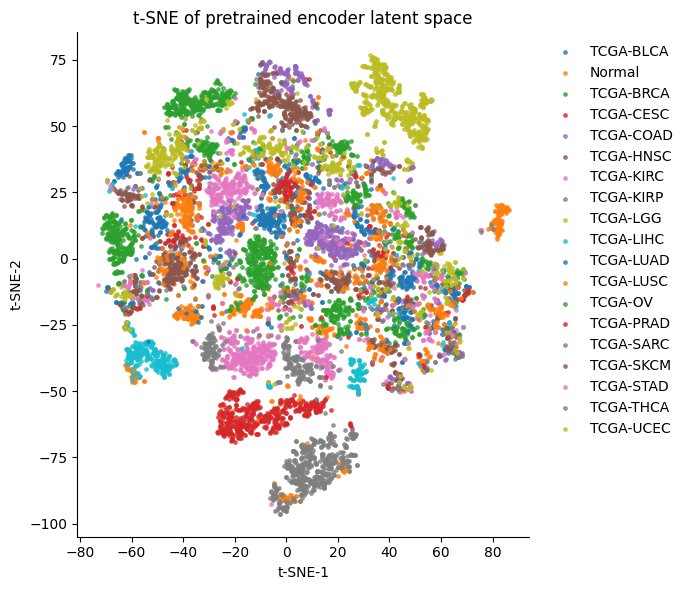

Saved: /Users/nourbf/Desktop/geniomhe/hamdi deep Ml/2526-m2geniomhe-SSL-tcga/tsne_plot_pretrained.png


array([[-37.301617 ,  24.365427 ],
       [ 17.473415 , -12.124719 ],
       [-52.54718  ,   4.500594 ],
       ...,
       [ 42.934944 ,  19.716127 ],
       [-30.540695 ,  13.0551195],
       [-18.740097 , -13.608455 ]], dtype=float32)

In [ ]:

save_dir='/Users/nourbf/Desktop/geniomhe/hamdi deep Ml/2526-m2geniomhe-SSL-tcga/'


TSNE_pretrained(save_dir,df2,'cancer_type')